# Bangkok PM2.5 Forecasting — Simple RNN vs LSTM

**Goal:** Predict the next 24 hours of PM2.5 concentration at *Kasetsart University Laboratory School 1, Chatuchak, Bangkok* using one year of historical air quality data (OpenAQ) combined with Bangkok weather data (Open-Meteo).

**Models compared:** Simple RNN vs LSTM — same hyperparameters, same data, different recurrent cell.

**Notebook structure:**
1. Install & import dependencies
2. Fetch PM2.5 data from OpenAQ
3. Fetch weather data from Open-Meteo
4. Merge, clean & explore data
5. Feature engineering
6. Dataset construction & chronological splitting
7. Model definitions (Simple RNN and LSTM)
8. Training loop
9. Evaluation (RMSE, MAE, AQI-based precision/recall)
10. Inference — next 24-hour forecast
11. Visualizations

## 1 — Install & import dependencies

In [28]:
# Install any packages not already present in Colab
!pip install openaq --quiet
!pip install requests pandas numpy matplotlib seaborn scikit-learn torch --quiet

In [29]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta, timezone
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device (GPU if available on Colab, else CPU) ─────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

Using device: cuda


## 2 — Fetch PM2.5 data from OpenAQ

In [30]:
# ── INSERT YOUR OPENAQ API KEY HERE ──────────────────────────────────────────
OPENAQ_API_KEY = '1006c7096765ce5a282272bd07bdd1a0d64c8c8197c0ef53ec954d69c8dfc731'

# ── Date range: last 1 year ───────────────────────────────────────────────────
END_DATE   = datetime.now(timezone.utc)
START_DATE = END_DATE - timedelta(days=365)

print(f'Fetching data from {START_DATE.date()} to {END_DATE.date()}')

Fetching data from 2025-05-07 to 2026-05-07


In [31]:
# ── OpenAQ v3 uses a sensors-based structure ──────────────────────────────────
# Measurements are no longer fetched via /locations/{id}/measurements.
# The correct path is:
#   1. GET /locations/{id}  → find the sensor IDs for pm25
#   2. GET /sensors/{sensor_id}/measurements  → pull the actual data

# Step 1: get the pm25 sensor ID for our location
def get_pm25_sensor_id(location_id: int, api_key: str) -> int:
    url     = f'https://api.openaq.org/v3/locations/{location_id}'
    headers = {'X-API-Key': api_key}

    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    info = r.json().get('results', [{}])[0]

    # Print all available sensors so we can confirm
    print("Available sensors at this station:")
    for sensor in info.get('sensors', []):
        print(f"  Sensor ID {sensor['id']:>8}  |  {sensor['parameter']['name']}  "
              f"({sensor['parameter']['units']})")

    # Find the pm25 sensor
    for sensor in info.get('sensors', []):
        if sensor['parameter']['name'].lower() == 'pm25':
            print(f"\n→ PM2.5 sensor ID: {sensor['id']}")
            return sensor['id']

    raise ValueError("No PM2.5 sensor found at this location.")




In [32]:
def fetch_pm25_hourly(sensor_id: int, api_key: str,
                      start: datetime, end: datetime,
                      page_limit: int = 1000) -> pd.DataFrame:
    url     = f'https://api.openaq.org/v3/sensors/{sensor_id}/measurements/hourly'
    headers = {'X-API-Key': api_key}
    records = []

    chunk_start = start
    chunk_num   = 0

    while chunk_start < end:
        chunk_end = min(chunk_start + timedelta(days=14), end)
        chunk_num += 1
        print(f'  Chunk {chunk_num:>2} | '
              f'{chunk_start.strftime("%Y-%m-%d")} → {chunk_end.strftime("%Y-%m-%d")}',
              end='  ')

        params = {
            'datetime_from' : chunk_start.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'datetime_to'   : chunk_end.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'limit'         : page_limit,
            'page'          : 1,
        }

        success = False
        for attempt in range(3):
            try:
                r = requests.get(url, headers=headers,
                                 params=params, timeout=60)
                r.raise_for_status()
                success = True
                break
            except Exception as e:
                print(f'\n    Attempt {attempt+1}/3 failed: {e}', end='')
                time.sleep(5)

        if not success:
            print(f'\n    Skipping chunk {chunk_num}.')
            chunk_start = chunk_end
            continue

        results = r.json().get('results', [])
        for m in results:
            records.append({
                'datetime': m['period']['datetimeFrom']['utc'],
                'pm25'    : m['value'],
            })

        print(f'→ {len(results):>4} records  (total: {len(records)})')
        chunk_start = chunk_end
        time.sleep(1.0)

    if not records:
        raise ValueError("No records returned. Check sensor ID and date range.")

    df = pd.DataFrame(records)
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
    df = df.set_index('datetime').sort_index()
    df = df[~df.index.duplicated(keep='first')]
    df = df[(df['pm25'] >= 0) & (df['pm25'] < 1000)]
    return df


# ── Fetch from both Kasetsart locations and merge ─────────────────────────────
LOCATION_IDS = [1235990, 5092510]

END_DATE   = datetime(2026, 5, 7, 7, 0, 0, tzinfo=timezone.utc)
START_DATE = END_DATE - timedelta(days=180)

print(f'Fetching hourly PM2.5 from {START_DATE.date()} to {END_DATE.date()}')

dfs = []
for loc_id in LOCATION_IDS:
    print(f'\nLooking up sensors for location {loc_id}...')
    try:
        sensor_id = get_pm25_sensor_id(loc_id, OPENAQ_API_KEY)
        df_s = fetch_pm25_hourly(sensor_id, OPENAQ_API_KEY, START_DATE, END_DATE)
        df_s = df_s['pm25'].resample('1h').mean()
        df_s.index = df_s.index.tz_convert('Asia/Bangkok')
        print(f'  → {df_s.notna().sum()} valid hours')
        dfs.append(df_s)
    except Exception as e:
        print(f'  → Skipping location {loc_id}: {e}')

df_aq_hourly = dfs[0].copy()
for fallback in dfs[1:]:
    df_aq_hourly = df_aq_hourly.fillna(fallback)

print(f'\nCombined valid hours : {df_aq_hourly.notna().sum()}')
print(f'Missing hours        : {df_aq_hourly.isna().sum()}')
df_aq_hourly.to_csv('pm25_raw.csv')
print('Saved to pm25_raw.csv')

Fetching hourly PM2.5 from 2025-11-08 to 2026-05-07

Looking up sensors for location 1235990...
Available sensors at this station:
  Sensor ID  7978581  |  pm1  (µg/m³)
  Sensor ID  7970840  |  pm1  (µg/m³)
  Sensor ID  7978591  |  pm10  (µg/m³)
  Sensor ID  7970903  |  pm10  (µg/m³)
  Sensor ID  6530181  |  pm25  (µg/m³)
  Sensor ID  7972252  |  relativehumidity  (%)
  Sensor ID  6530169  |  temperature  (c)
  Sensor ID  7972274  |  um003  (particles/cm³)

→ PM2.5 sensor ID: 6530181
  Chunk  1 | 2025-11-08 → 2025-11-22  →  316 records  (total: 316)
  Chunk  2 | 2025-11-22 → 2025-12-06  →  198 records  (total: 514)
  Chunk  3 | 2025-12-06 → 2025-12-20  →    0 records  (total: 514)
  Chunk  4 | 2025-12-20 → 2026-01-03  →    0 records  (total: 514)
  Chunk  5 | 2026-01-03 → 2026-01-17  →   52 records  (total: 566)
  Chunk  6 | 2026-01-17 → 2026-01-31  →  336 records  (total: 902)
  Chunk  7 | 2026-01-31 → 2026-02-14  →  336 records  (total: 1238)
  Chunk  8 | 2026-02-14 → 2026-02-28  →  

## 3 — Fetch weather data from Open-Meteo

In [33]:
# ── Open-Meteo historical archive — no API key required ──────────────────────
# We request hourly weather variables for Bangkok (central coords).
# The archive endpoint covers up to yesterday; today onwards needs the forecast API.

def fetch_openmeteo(lat: float, lon: float,
                    start: datetime, end: datetime) -> pd.DataFrame:
    """
    Fetch hourly weather history from Open-Meteo archive API.
    Returns a DataFrame indexed by local Bangkok time.
    """
    url    = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude'               : lat,
        'longitude'              : lon,
        'start_date'             : start.strftime('%Y-%m-%d'),
        'end_date'               : end.strftime('%Y-%m-%d'),
        'hourly'                 : [
            'temperature_2m',           # °C
            'relative_humidity_2m',     # %
            'precipitation',            # mm
            'windspeed_10m',            # km/h
        ],
        'timezone'               : 'Asia/Bangkok',
        'wind_speed_unit'        : 'kmh',
        'precipitation_unit'     : 'mm',
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data['hourly'])
    df.rename(columns={'time': 'datetime'}, inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime')

    # Make index timezone-aware (Bangkok, UTC+7)
    df.index = df.index.tz_localize('Asia/Bangkok', ambiguous='infer',
                                     nonexistent='shift_forward')
    return df


# Bangkok city centre coordinates
BKK_LAT, BKK_LON = 13.7563, 100.5018

print('Fetching weather data from Open-Meteo...')
df_weather = fetch_openmeteo(BKK_LAT, BKK_LON, START_DATE, END_DATE)

print(f'Weather rows : {len(df_weather)}')
print(f'Columns      : {list(df_weather.columns)}')
df_weather.head()

Fetching weather data from Open-Meteo...
Weather rows : 4344
Columns      : ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'windspeed_10m']


,temperature_2m,relative_humidity_2m,precipitation,windspeed_10m
datetime,,,,
2025-11-08 00:00:00+07:00,26.6,93,0.0,2.6
2025-11-08 01:00:00+07:00,26.2,92,0.0,6.8
2025-11-08 02:00:00+07:00,26.0,92,1.6,7.3
2025-11-08 03:00:00+07:00,25.4,95,1.5,2.7
2025-11-08 04:00:00+07:00,25.0,93,0.5,4.7


In [34]:
# Save weather to disk
df_weather.to_csv('weather_raw.csv')
print('Saved to weather_raw.csv')

Saved to weather_raw.csv


## 4 — Merge, clean & explore data

In [35]:
# ── Merge on the hourly datetime index ───────────────────────────────────────
# Both DataFrames are already indexed by Bangkok local time.

df = df_weather.copy()
df['pm25'] = df_aq_hourly  # align by index (NaN where no AQ reading)

print(f'Merged shape before cleaning : {df.shape}')
print(f'\nMissing values per column:')
print(df.isna().sum())

Merged shape before cleaning : (4344, 5)

Missing values per column:
temperature_2m            0
relative_humidity_2m      0
precipitation             0
windspeed_10m             0
pm25                    227
dtype: int64


In [36]:
# ── Gap filling strategy ──────────────────────────────────────────────────────
# Weather data from Open-Meteo is virtually complete — forward-fill any rare gaps.
# PM2.5 gaps up to 3 consecutive hours are interpolated (sensor dropout);
# longer gaps are left as NaN and those rows are dropped.

# Weather columns: forward-fill
weather_cols = ['temperature_2m', 'relative_humidity_2m',
                'precipitation', 'windspeed_10m']
df[weather_cols] = df[weather_cols].ffill()

# PM2.5: linear interpolation for gaps ≤ 3 hours
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3)

# Drop remaining rows where PM2.5 is still NaN (long sensor outages)
df = df.dropna(subset=['pm25'])

print(f'Shape after cleaning : {df.shape}')
print(f'Remaining NaN        : {df.isna().sum().sum()}')

Shape after cleaning : (4163, 5)
Remaining NaN        : 0


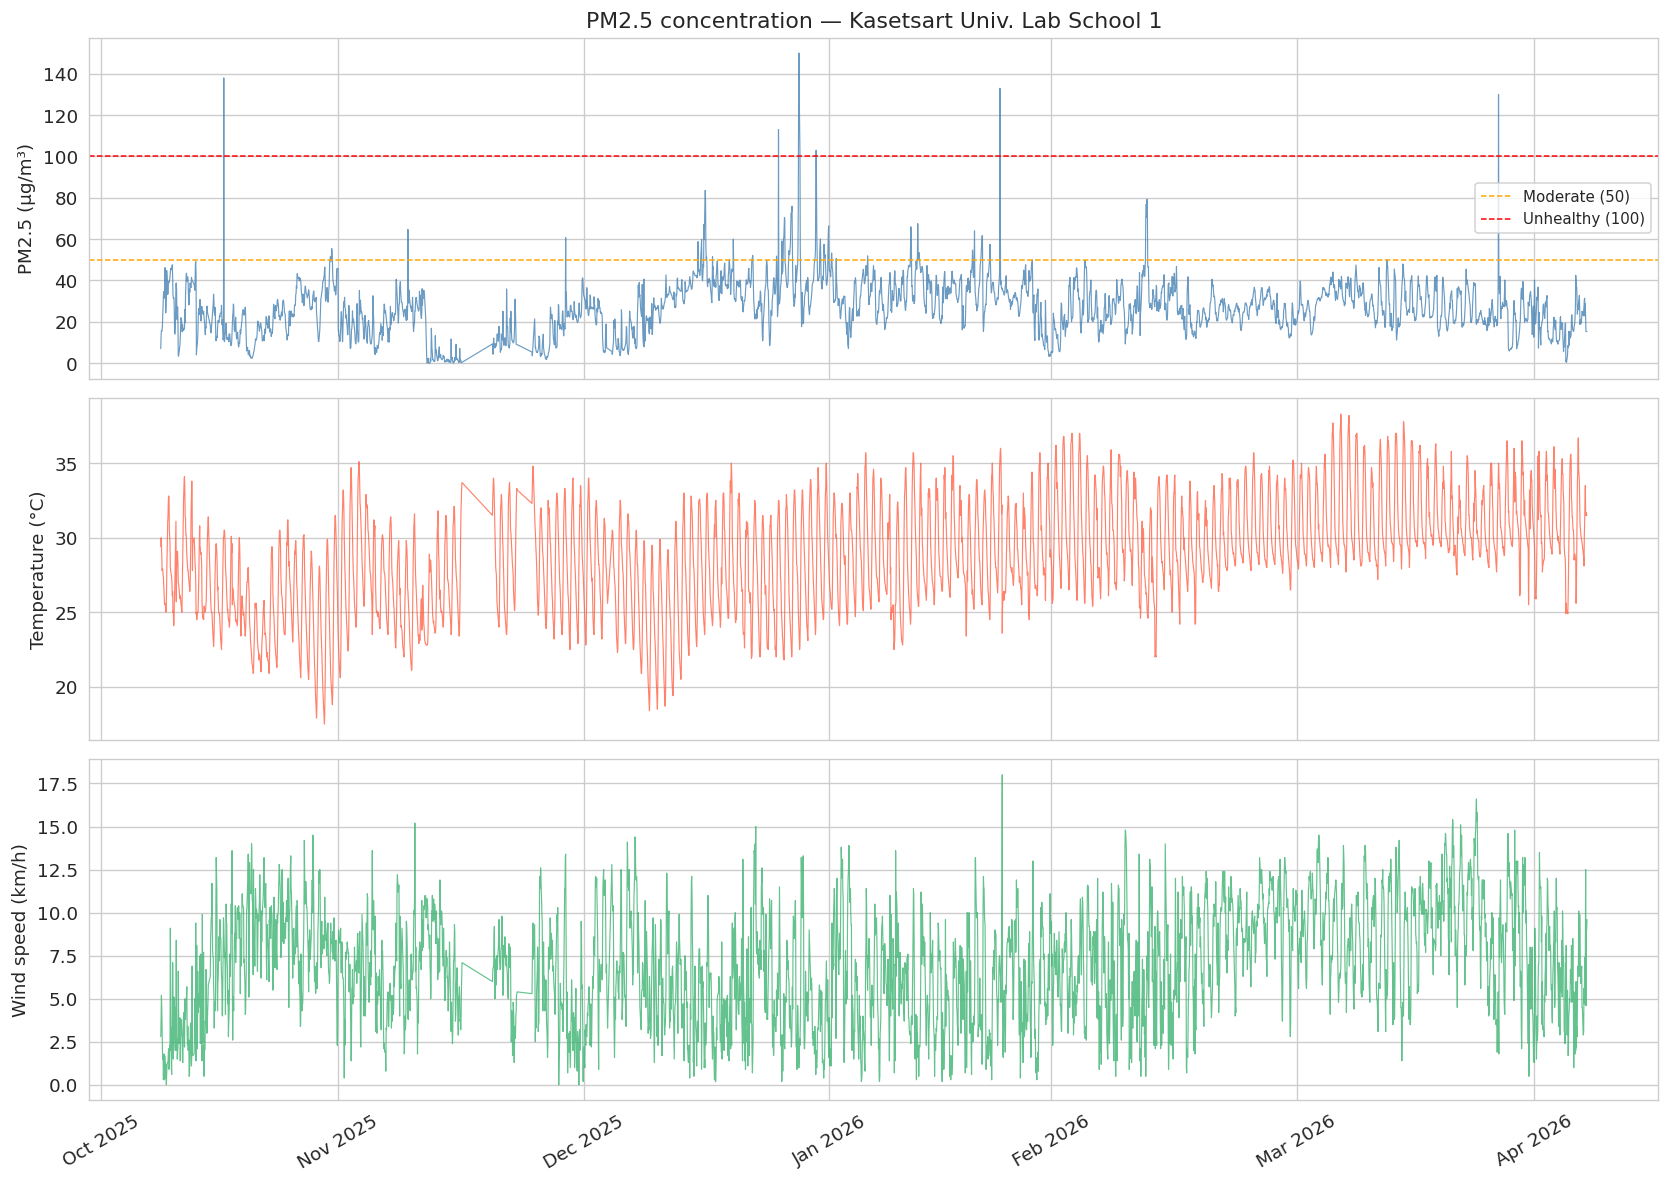


PM2.5 summary statistics:
count    4163.00
mean       27.06
std        13.13
min         0.00
25%        19.10
50%        26.90
75%        34.95
max       150.00
Name: pm25, dtype: float64


In [37]:
# ── Exploratory visualisation ─────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# PM2.5 time series
axes[0].plot(df.index, df['pm25'], color='steelblue', linewidth=0.7, alpha=0.8)
axes[0].axhline(50,  color='orange', linestyle='--', linewidth=0.9, label='Moderate (50)')
axes[0].axhline(100, color='red',    linestyle='--', linewidth=0.9, label='Unhealthy (100)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('PM2.5 concentration — Kasetsart Univ. Lab School 1')
axes[0].legend(fontsize=9)

# Temperature
axes[1].plot(df.index, df['temperature_2m'], color='tomato', linewidth=0.7, alpha=0.8)
axes[1].set_ylabel('Temperature (°C)')

# Wind speed
axes[2].plot(df.index, df['windspeed_10m'], color='mediumseagreen', linewidth=0.7, alpha=0.8)
axes[2].set_ylabel('Wind speed (km/h)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('eda_timeseries.png', bbox_inches='tight')
plt.show()
print('\nPM2.5 summary statistics:')
print(df['pm25'].describe().round(2))

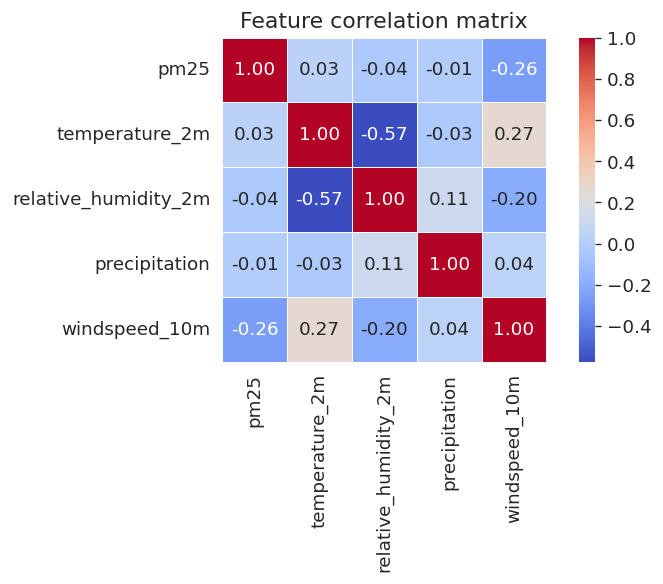

In [38]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['pm25', 'temperature_2m', 'relative_humidity_2m',
           'precipitation', 'windspeed_10m']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

## 5 — Feature engineering

In [39]:
# ── Feature engineering ───────────────────────────────────────────────────────
#
# Features used (all at hourly resolution):
#   1. pm25               — raw target variable
#   2. pm25_roll24        — 24-hour rolling mean of PM2.5 (captures daily trend)
#   3. hour_sin / hour_cos — cyclical encoding of hour-of-day (avoids 23→0 jump)
#   4. relative_humidity_2m
#   5. windspeed_10m
#   6. temperature_2m
#   7. precipitation
#
# Design note: sine/cosine encoding is used for hour-of-day instead of a raw
# integer so the model understands that hour 23 and hour 0 are adjacent.

df_feat = df.copy()

# 24-hour rolling mean (min_periods=1 avoids NaN at the start)
df_feat['pm25_roll24'] = df_feat['pm25'].rolling(window=24, min_periods=1).mean()

# Cyclical hour-of-day encoding
hour = df_feat.index.hour
df_feat['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * hour / 24)

# Select final feature columns (order matters for later indexing)
FEATURE_COLS = [
    'pm25',
    'pm25_roll24',
    'hour_sin',
    'hour_cos',
    'relative_humidity_2m',
    'windspeed_10m',
    'temperature_2m',
    'precipitation',
]
TARGET_COL   = 'pm25'          # what we predict
TARGET_IDX   = 0               # index of pm25 in FEATURE_COLS
N_FEATURES   = len(FEATURE_COLS)

df_feat = df_feat[FEATURE_COLS].dropna()

print(f'Feature matrix shape : {df_feat.shape}')
print(f'Features             : {FEATURE_COLS}')
df_feat.head()

Feature matrix shape : (4163, 8)
Features             : ['pm25', 'pm25_roll24', 'hour_sin', 'hour_cos', 'relative_humidity_2m', 'windspeed_10m', 'temperature_2m', 'precipitation']


,pm25,pm25_roll24,hour_sin,hour_cos,relative_humidity_2m,windspeed_10m,temperature_2m,precipitation
datetime,,,,,,,,
2025-11-08 14:00:00+07:00,7.04,7.040000,-0.500000,-8.660254e-01,75,2.8,29.4,0.0
2025-11-08 15:00:00+07:00,13.20,10.120000,-0.707107,-7.071068e-01,70,3.8,30.0,0.0
2025-11-08 16:00:00+07:00,15.80,12.013333,-0.866025,-5.000000e-01,72,5.2,29.6,0.2
2025-11-08 17:00:00+07:00,15.40,12.860000,-0.965926,-2.588190e-01,76,4.5,28.9,0.1
2025-11-08 18:00:00+07:00,15.90,13.468000,-1.000000,-1.836970e-16,85,3.3,27.8,0.0


## 6 — Dataset construction & chronological splitting

In [40]:
# ── Chronological train / validation / test split (70 / 15 / 15) ─────────────
# IMPORTANT: We never shuffle time-series data. Shuffling would let the model
# 'see' the future during training, leading to unrealistically good metrics.

N = len(df_feat)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

df_train = df_feat.iloc[:train_end]
df_val   = df_feat.iloc[train_end:val_end]
df_test  = df_feat.iloc[val_end:]

print(f'Total  hours : {N}')
print(f'Train  hours : {len(df_train)}  ({df_train.index[0].date()} → {df_train.index[-1].date()})')
print(f'Val    hours : {len(df_val)}  ({df_val.index[0].date()} → {df_val.index[-1].date()})')
print(f'Test   hours : {len(df_test)}  ({df_test.index[0].date()} → {df_test.index[-1].date()})')

Total  hours : 4163
Train  hours : 2914  (2025-11-08 → 2026-03-16)
Val    hours : 624  (2026-03-16 → 2026-04-11)
Test   hours : 625  (2026-04-11 → 2026-05-07)


In [41]:
# ── MinMax normalisation ──────────────────────────────────────────────────────
# Fit the scaler ONLY on training data to prevent data leakage from val/test.

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(df_train.values)
val_scaled   = scaler.transform(df_val.values)
test_scaled  = scaler.transform(df_test.values)

print('Scaler fitted on training set only (no leakage).')
print(f'Train scaled shape : {train_scaled.shape}')

Scaler fitted on training set only (no leakage).
Train scaled shape : (2914, 8)


In [42]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
#
# Hyperparameters:
#   SEQ_LEN    = 168  hours  (7-day lookback window)
#   PRED_LEN   = 24   hours  (24-hour forecast horizon)
#
# Each sample is:
#   X : (SEQ_LEN, N_FEATURES)  — past 168 hours of all features
#   y : (PRED_LEN,)            — next 24 hours of PM2.5 only

SEQ_LEN  = 168   # lookback window (7 days × 24 hours)
PRED_LEN = 24    # forecast horizon


class PM25Dataset(Dataset):
    """
    Sliding-window dataset for multi-step PM2.5 forecasting.
    X contains all features for SEQ_LEN past hours.
    y contains PM2.5 values for the next PRED_LEN hours.
    """
    def __init__(self, data: np.ndarray, seq_len: int, pred_len: int,
                 target_idx: int):
        self.data       = data
        self.seq_len    = seq_len
        self.pred_len   = pred_len
        self.target_idx = target_idx

    def __len__(self):
        # Number of valid windows
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x_start = idx
        x_end   = idx + self.seq_len
        y_start = x_end
        y_end   = y_start + self.pred_len

        X = self.data[x_start:x_end]                          # (168, 8)
        y = self.data[y_start:y_end, self.target_idx]          # (24,)

        return (torch.tensor(X, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32))


BATCH_SIZE = 64

train_ds = PM25Dataset(train_scaled, SEQ_LEN, PRED_LEN, TARGET_IDX)
val_ds   = PM25Dataset(val_scaled,   SEQ_LEN, PRED_LEN, TARGET_IDX)
test_ds  = PM25Dataset(test_scaled,  SEQ_LEN, PRED_LEN, TARGET_IDX)

# shuffle=False preserves chronological order within each split
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')
print(f'Test  samples : {len(test_ds)}')

# Sanity check shapes
xb, yb = next(iter(train_dl))
print(f'\nBatch X shape : {xb.shape}  — (batch, seq_len, n_features)')
print(f'Batch y shape : {yb.shape}  — (batch, pred_len)')

Train samples : 2723
Val   samples : 433
Test  samples : 434

Batch X shape : torch.Size([64, 168, 8])  — (batch, seq_len, n_features)
Batch y shape : torch.Size([64, 24])  — (batch, pred_len)


## 7 — Model definitions

### Design choices — why these architectures?

**Simple RNN**  
A vanilla RNN applies the same learned weight matrix at every time step: `h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)`. It is the simplest recurrent architecture. Its key weakness is the *vanishing gradient* problem: gradients shrink exponentially as they flow back through long sequences, so the model struggles to connect patterns 168 steps apart. We include it as a **baseline** to quantify exactly how much the gating mechanism of LSTM helps.

**LSTM**  
The Long Short-Term Memory cell adds three gates (input, forget, output) and a separate cell state. The forget gate allows the model to explicitly decide what to remember across long intervals — critical for air quality, where multi-day pollution episodes (the burning season in Thailand) require remembering conditions from days ago. We expect LSTM to outperform Simple RNN on the 168-hour window.

**Shared hyperparameters (for fair comparison)**  
- Hidden size : 128  
- Layers      : 2  
- Dropout     : 0.2  
- Output      : fully-connected head → 24 values

In [43]:
# ── Shared hyperparameters ────────────────────────────────────────────────────
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.2
LEARNING_RATE = 1e-3
N_EPOCHS     = 50


# ── Simple RNN model ──────────────────────────────────────────────────────────
class SimpleRNN(nn.Module):
    """
    Vanilla RNN for multi-step PM2.5 forecasting.

    Architecture:
      Input  : (batch, seq_len, n_features)
      RNN    : 2-layer tanh RNN with dropout between layers
      FC head: hidden_size → pred_len
      Output : (batch, pred_len)

    We take the hidden state of the LAST time step and pass it through
    a linear layer to produce all 24 future values at once (direct
    multi-output strategy, simpler than autoregressive decoding).
    """
    def __init__(self, n_features: int, hidden_size: int,
                 num_layers: int, pred_len: int, dropout: float):
        super().__init__()
        self.rnn = nn.RNN(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,        # input shape: (batch, seq, feature)
            dropout     = dropout if num_layers > 1 else 0.0,
            nonlinearity= 'tanh',
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, pred_len)

    def forward(self, x):
        # x         : (batch, seq_len, n_features)
        # out       : (batch, seq_len, hidden_size)
        # h_n       : (num_layers, batch, hidden_size)
        out, h_n = self.rnn(x)
        # Use the last time-step output
        last_hidden = out[:, -1, :]          # (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)          # (batch, pred_len)


# ── LSTM model ────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    """
    LSTM for multi-step PM2.5 forecasting.

    Architecture is identical to SimpleRNN above, with nn.RNN replaced by
    nn.LSTM. The only structural difference is the cell state (c_n) returned
    by the LSTM — we ignore it at the output stage and only use the hidden
    state, keeping the comparison fair.
    """
    def __init__(self, n_features: int, hidden_size: int,
                 num_layers: int, pred_len: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, pred_len)

    def forward(self, x):
        # x         : (batch, seq_len, n_features)
        # out       : (batch, seq_len, hidden_size)
        # (h_n, c_n): each (num_layers, batch, hidden_size)
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]          # (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)          # (batch, pred_len)


# ── Instantiate both models ───────────────────────────────────────────────────
rnn_model  = SimpleRNN(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, PRED_LEN, DROPOUT).to(DEVICE)
lstm_model = LSTMModel(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, PRED_LEN, DROPOUT).to(DEVICE)

print('── Simple RNN ──')
print(rnn_model)
total_rnn = sum(p.numel() for p in rnn_model.parameters())
print(f'Total parameters: {total_rnn:,}')

print('\n── LSTM ──')
print(lstm_model)
total_lstm = sum(p.numel() for p in lstm_model.parameters())
print(f'Total parameters: {total_lstm:,}')

── Simple RNN ──
SimpleRNN(
  (rnn): RNN(8, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=24, bias=True)
)
Total parameters: 53,784

── LSTM ──
LSTMModel(
  (lstm): LSTM(8, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=24, bias=True)
)
Total parameters: 205,848


## 8 — Training loop

In [45]:
# ── Training and validation functions ─────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion):
    """Run one full pass over the training set. Returns mean loss."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(X_batch)           # (batch, pred_len)
        loss  = criterion(preds, y_batch)
        loss.backward()

        # Gradient clipping prevents exploding gradients (especially for RNN)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Compute mean loss on a DataLoader without updating weights."""
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        preds   = model(X_batch)
        loss    = criterion(preds, y_batch)
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader,
                n_epochs: int, lr: float, model_name: str):
    """
    Full training loop with:
      - MSE loss (standard for regression)
      - Adam optimiser
      - ReduceLROnPlateau scheduler (halves LR if val loss stalls for 5 epochs)
      - Early stopping (patience = 10 epochs)
      - Best model checkpoint saved to disk
    Returns history dict with train/val loss lists.
    """
    criterion  = nn.MSELoss()
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss  = float('inf')
    patience_count = 0
    PATIENCE       = 10
    history        = {'train_loss': [], 'val_loss': []}
    checkpoint_path = f'best_{model_name}.pt'

    for epoch in range(1, n_epochs + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        v_loss = evaluate(model, val_loader, criterion)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)

        scheduler.step(v_loss)

        if v_loss < best_val_loss:
            best_val_loss  = v_loss
            patience_count = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_count += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{model_name}] Epoch {epoch:>3}/{n_epochs}  '
                  f'train_loss={t_loss:.5f}  val_loss={v_loss:.5f}  '
                  f'best={best_val_loss:.5f}')

        if patience_count >= PATIENCE:
            print(f'[{model_name}] Early stopping at epoch {epoch}.')
            break

    # Reload the best weights
    model.load_state_dict(torch.load(checkpoint_path))
    print(f'[{model_name}] Best val loss: {best_val_loss:.5f}')
    return history

In [46]:
# ── Train Simple RNN ──────────────────────────────────────────────────────────
print('Training Simple RNN...')
rnn_history = train_model(rnn_model, train_dl, val_dl, N_EPOCHS, LEARNING_RATE, 'SimpleRNN')

Training Simple RNN...
[SimpleRNN] Epoch   1/50  train_loss=0.01374  val_loss=0.00299  best=0.00299
[SimpleRNN] Epoch   5/50  train_loss=0.00779  val_loss=0.00234  best=0.00212
[SimpleRNN] Epoch  10/50  train_loss=0.00630  val_loss=0.00254  best=0.00212
[SimpleRNN] Early stopping at epoch 12.
[SimpleRNN] Best val loss: 0.00212


In [47]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
print('Training LSTM...')
lstm_history = train_model(lstm_model, train_dl, val_dl,
                            N_EPOCHS, LEARNING_RATE, 'LSTM')

Training LSTM...
[LSTM] Epoch   1/50  train_loss=0.01544  val_loss=0.00459  best=0.00459
[LSTM] Epoch   5/50  train_loss=0.01113  val_loss=0.00262  best=0.00213
[LSTM] Epoch  10/50  train_loss=0.00909  val_loss=0.00177  best=0.00177
[LSTM] Epoch  15/50  train_loss=0.00593  val_loss=0.00206  best=0.00177
[LSTM] Epoch  20/50  train_loss=0.00578  val_loss=0.00228  best=0.00177
[LSTM] Early stopping at epoch 20.
[LSTM] Best val loss: 0.00177


## 9 — Evaluation

In [48]:
# ── Collect predictions on the test set ──────────────────────────────────────

@torch.no_grad()
def get_predictions(model, loader, scaler, target_idx: int, n_features: int):
    """
    Run the model on all batches in loader and return:
      preds_orig : predictions in original µg/m³ scale
      truth_orig : ground truth in original µg/m³ scale
    Inverse-scaling is applied to PM2.5 only (column target_idx).
    """
    model.eval()
    all_preds, all_truth = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        preds   = model(X_batch).cpu().numpy()  # (batch, pred_len)
        truth   = y_batch.numpy()               # (batch, pred_len)
        all_preds.append(preds)
        all_truth.append(truth)

    all_preds = np.concatenate(all_preds, axis=0)  # (N_samples, pred_len)
    all_truth = np.concatenate(all_truth, axis=0)

    # Inverse-transform: build a dummy matrix of zeros, put our column back,
    # then inverse-transform, then extract the target column.
    def inv_scale(arr_2d):
        """arr_2d shape: (N_samples * pred_len,) → scalar µg/m³"""
        dummy = np.zeros((len(arr_2d), n_features))
        dummy[:, target_idx] = arr_2d
        return scaler.inverse_transform(dummy)[:, target_idx]

    flat_preds = all_preds.flatten()
    flat_truth = all_truth.flatten()

    return inv_scale(flat_preds), inv_scale(flat_truth), all_preds, all_truth


rnn_preds_flat,  rnn_truth_flat,  rnn_preds_all,  rnn_truth_all  = \
    get_predictions(rnn_model,  test_dl, scaler, TARGET_IDX, N_FEATURES)

lstm_preds_flat, lstm_truth_flat, lstm_preds_all, lstm_truth_all = \
    get_predictions(lstm_model, test_dl, scaler, TARGET_IDX, N_FEATURES)

print('Predictions collected.')
print(f'Flat shape: {rnn_preds_flat.shape}')

Predictions collected.
Flat shape: (10416,)


In [49]:
# ── Regression metrics : RMSE, MAE ────────────────────────────────────────────

def rmse(truth, preds):
    return np.sqrt(np.mean((truth - preds) ** 2))

def mae(truth, preds):
    return np.mean(np.abs(truth - preds))


rnn_rmse  = rmse(rnn_truth_flat,  rnn_preds_flat)
rnn_mae   = mae( rnn_truth_flat,  rnn_preds_flat)
lstm_rmse = rmse(lstm_truth_flat, lstm_preds_flat)
lstm_mae  = mae( lstm_truth_flat, lstm_preds_flat)

print('─── Regression metrics (test set) ───')
print(f'{"Model":<14} {"RMSE":>8} {"MAE":>8}')
print(f'{"Simple RNN":<14} {rnn_rmse:>8.3f} {rnn_mae:>8.3f}')
print(f'{"LSTM":<14} {lstm_rmse:>8.3f} {lstm_mae:>8.3f}')

─── Regression metrics (test set) ───
Model              RMSE      MAE
Simple RNN       11.073    8.424
LSTM             10.668    7.859


In [50]:
# ── AQI-based classification metrics : Precision, Recall, F1 ─────────────────
#
# We convert continuous PM2.5 predictions to AQI categories using Thai/WHO
# breakpoints:
#   0  — Good       :  0 –  25 µg/m³
#   1  — Moderate   : 26 –  50 µg/m³
#   2  — Unhealthy  : 51 – 100 µg/m³
#   3  — Very unhealthy / Hazardous : > 100 µg/m³
#
# These thresholds match the Thai Pollution Control Department standard.

BINS   = [0, 25, 50, 100, np.inf]
LABELS = [0, 1, 2, 3]  # Good / Moderate / Unhealthy / Hazardous

def to_aqi_class(arr):
    """Convert continuous PM2.5 array to integer AQI category."""
    return np.digitize(np.clip(arr, 0, None), bins=BINS[1:])  # 0-indexed classes


rnn_truth_cls  = to_aqi_class(rnn_truth_flat)
rnn_preds_cls  = to_aqi_class(rnn_preds_flat)
lstm_truth_cls = to_aqi_class(lstm_truth_flat)
lstm_preds_cls = to_aqi_class(lstm_preds_flat)

print('─── Classification metrics (AQI categories, macro average) ───')
AQI_NAMES = ['Good', 'Moderate', 'Unhealthy', 'Hazardous']

for name, t_cls, p_cls in [('Simple RNN', rnn_truth_cls, rnn_preds_cls),
                             ('LSTM',       lstm_truth_cls, lstm_preds_cls)]:
    prec = precision_score(t_cls, p_cls, average='macro', zero_division=0)
    rec  = recall_score(   t_cls, p_cls, average='macro', zero_division=0)
    f1   = f1_score(       t_cls, p_cls, average='macro', zero_division=0)
    print(f'\n{name}:')
    print(f'  Precision (macro) : {prec:.3f}')
    print(f'  Recall    (macro) : {rec:.3f}')
    print(f'  F1        (macro) : {f1:.3f}')

─── Classification metrics (AQI categories, macro average) ───

Simple RNN:
  Precision (macro) : 0.341
  Recall    (macro) : 0.339
  F1        (macro) : 0.268

LSTM:
  Precision (macro) : 0.385
  Recall    (macro) : 0.390
  F1        (macro) : 0.374


## 10 — Inference: next 24-hour forecast

In [51]:
# ── Forecast the next 24 hours from the most recent data point ────────────────
#
# We take the last SEQ_LEN (168) rows of the full dataset as the input window
# and ask both models to predict the next 24 hours.

@torch.no_grad()
def forecast_next_24h(model, df_full: pd.DataFrame,
                       scaler, seq_len: int, n_features: int,
                       target_idx: int) -> np.ndarray:
    """
    Given the full feature DataFrame, extract the last seq_len rows,
    scale them, run the model, and return the 24-hour forecast
    in original µg/m³ units.
    """
    model.eval()

    # Extract last 168 hours
    window = df_full.values[-seq_len:]             # (168, n_features)
    window_scaled = scaler.transform(window)        # normalise

    x = torch.tensor(window_scaled, dtype=torch.float32)
    x = x.unsqueeze(0).to(DEVICE)                  # (1, 168, n_features)

    pred_scaled = model(x).cpu().numpy().flatten()  # (24,)

    # Inverse-scale
    dummy = np.zeros((24, n_features))
    dummy[:, target_idx] = pred_scaled
    pred_orig = scaler.inverse_transform(dummy)[:, target_idx]

    return np.clip(pred_orig, 0, None)  # PM2.5 can't be negative


rnn_forecast  = forecast_next_24h(rnn_model,  df_feat, scaler,
                                   SEQ_LEN, N_FEATURES, TARGET_IDX)
lstm_forecast = forecast_next_24h(lstm_model, df_feat, scaler,
                                   SEQ_LEN, N_FEATURES, TARGET_IDX)

# Build forecast timestamps
last_ts     = df_feat.index[-1]
forecast_ts = pd.date_range(start=last_ts + pd.Timedelta(hours=1),
                             periods=24, freq='h')

df_forecast = pd.DataFrame({
    'datetime'   : forecast_ts,
    'rnn_pm25'   : rnn_forecast,
    'lstm_pm25'  : lstm_forecast,
    'aqi_rnn'    : [AQI_NAMES[c] for c in to_aqi_class(rnn_forecast)],
    'aqi_lstm'   : [AQI_NAMES[c] for c in to_aqi_class(lstm_forecast)],
}).set_index('datetime')

print('24-hour PM2.5 forecast:')
print(df_forecast.round(2).to_string())

24-hour PM2.5 forecast:
                           rnn_pm25  lstm_pm25   aqi_rnn  aqi_lstm
datetime                                                          
2026-05-07 17:00:00+07:00     26.81      22.98  Moderate      Good
2026-05-07 18:00:00+07:00     26.40      22.67  Moderate      Good
2026-05-07 19:00:00+07:00     27.94      24.13  Moderate      Good
2026-05-07 20:00:00+07:00     25.38      24.84  Moderate      Good
2026-05-07 21:00:00+07:00     26.27      24.67  Moderate      Good
2026-05-07 22:00:00+07:00     26.45      25.21  Moderate  Moderate
2026-05-07 23:00:00+07:00     26.94      25.59  Moderate  Moderate
2026-05-08 00:00:00+07:00     25.27      24.98  Moderate      Good
2026-05-08 01:00:00+07:00     26.34      24.34  Moderate      Good
2026-05-08 02:00:00+07:00     29.10      24.31  Moderate      Good
2026-05-08 03:00:00+07:00     26.70      25.65  Moderate  Moderate
2026-05-08 04:00:00+07:00     28.70      24.88  Moderate      Good
2026-05-08 05:00:00+07:00     26.44   

## 11 — Visualizations

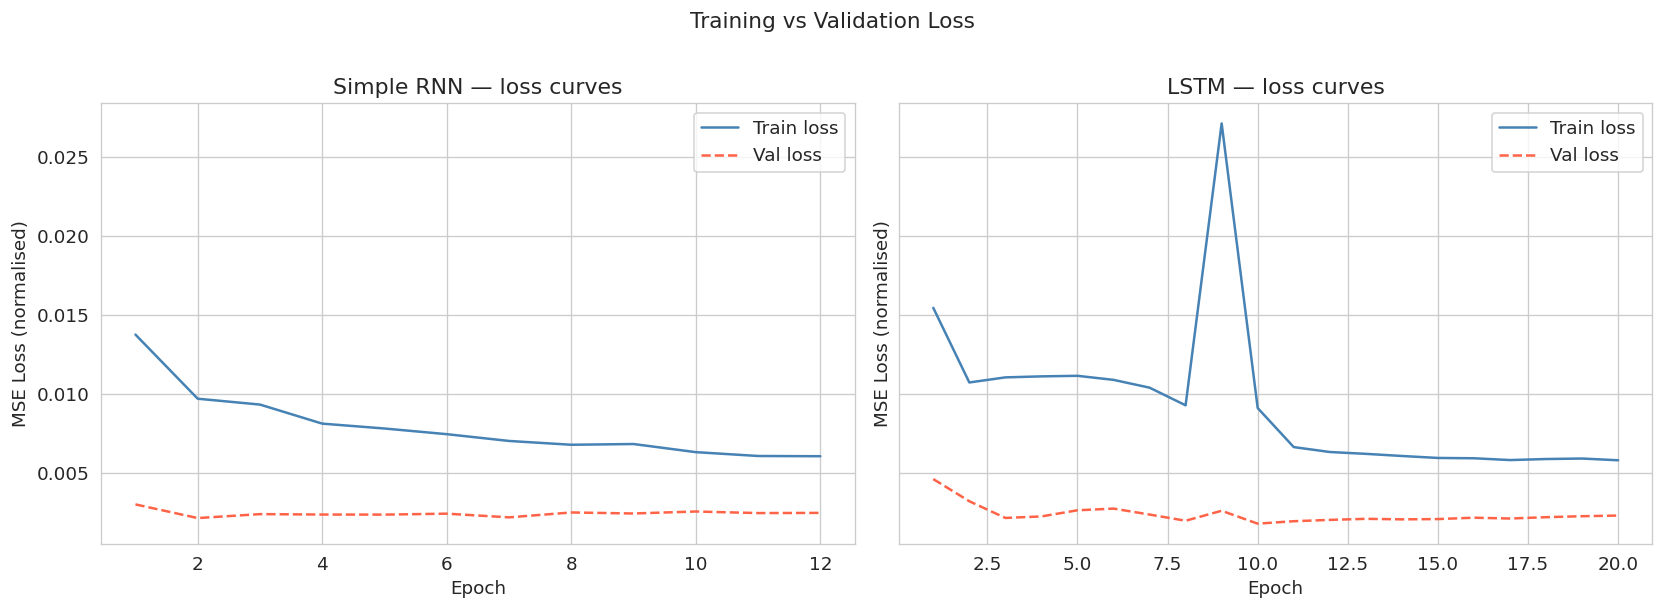

In [52]:
# ── Plot 1: Training & validation loss curves ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, history, title in zip(
    axes,
    [rnn_history, lstm_history],
    ['Simple RNN — loss curves', 'LSTM — loss curves']
):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
    ax.plot(epochs, history['val_loss'],   label='Val loss',   color='tomato',
            linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss (normalised)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Training vs Validation Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight')
plt.show()

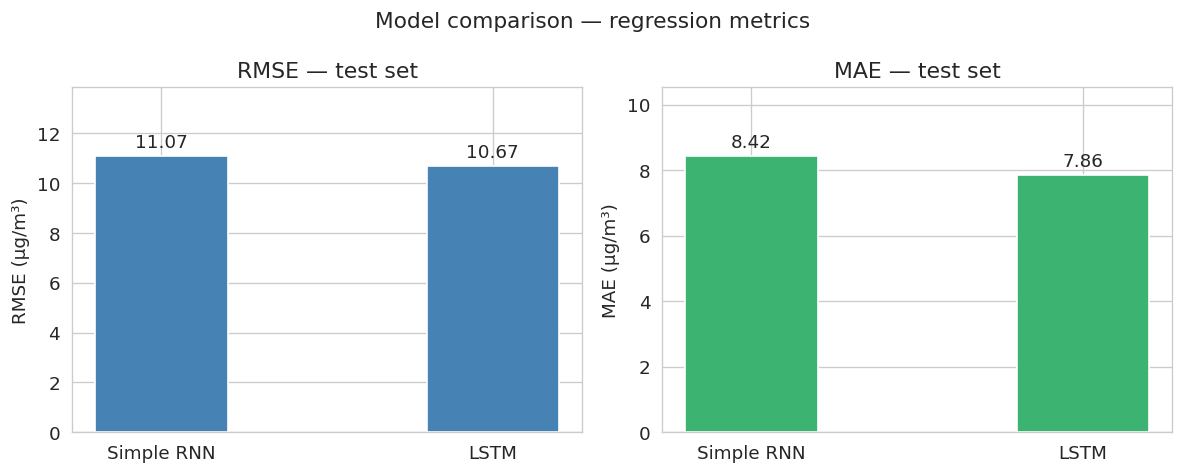

In [53]:
# ── Plot 2: RMSE / MAE comparison bar chart ────────────────────────────────────

metrics_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM'],
    'RMSE' : [rnn_rmse,  lstm_rmse],
    'MAE'  : [rnn_mae,   lstm_mae],
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes, ['RMSE', 'MAE'], ['steelblue', 'mediumseagreen']):
    bars = ax.bar(metrics_df['Model'], metrics_df[col], color=color, width=0.4)
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.set_ylabel(f'{col} (µg/m³)')
    ax.set_title(f'{col} — test set')
    ax.set_ylim(0, metrics_df[col].max() * 1.25)

plt.suptitle('Model comparison — regression metrics', fontsize=13)
plt.tight_layout()
plt.savefig('metrics_bar.png', bbox_inches='tight')
plt.show()

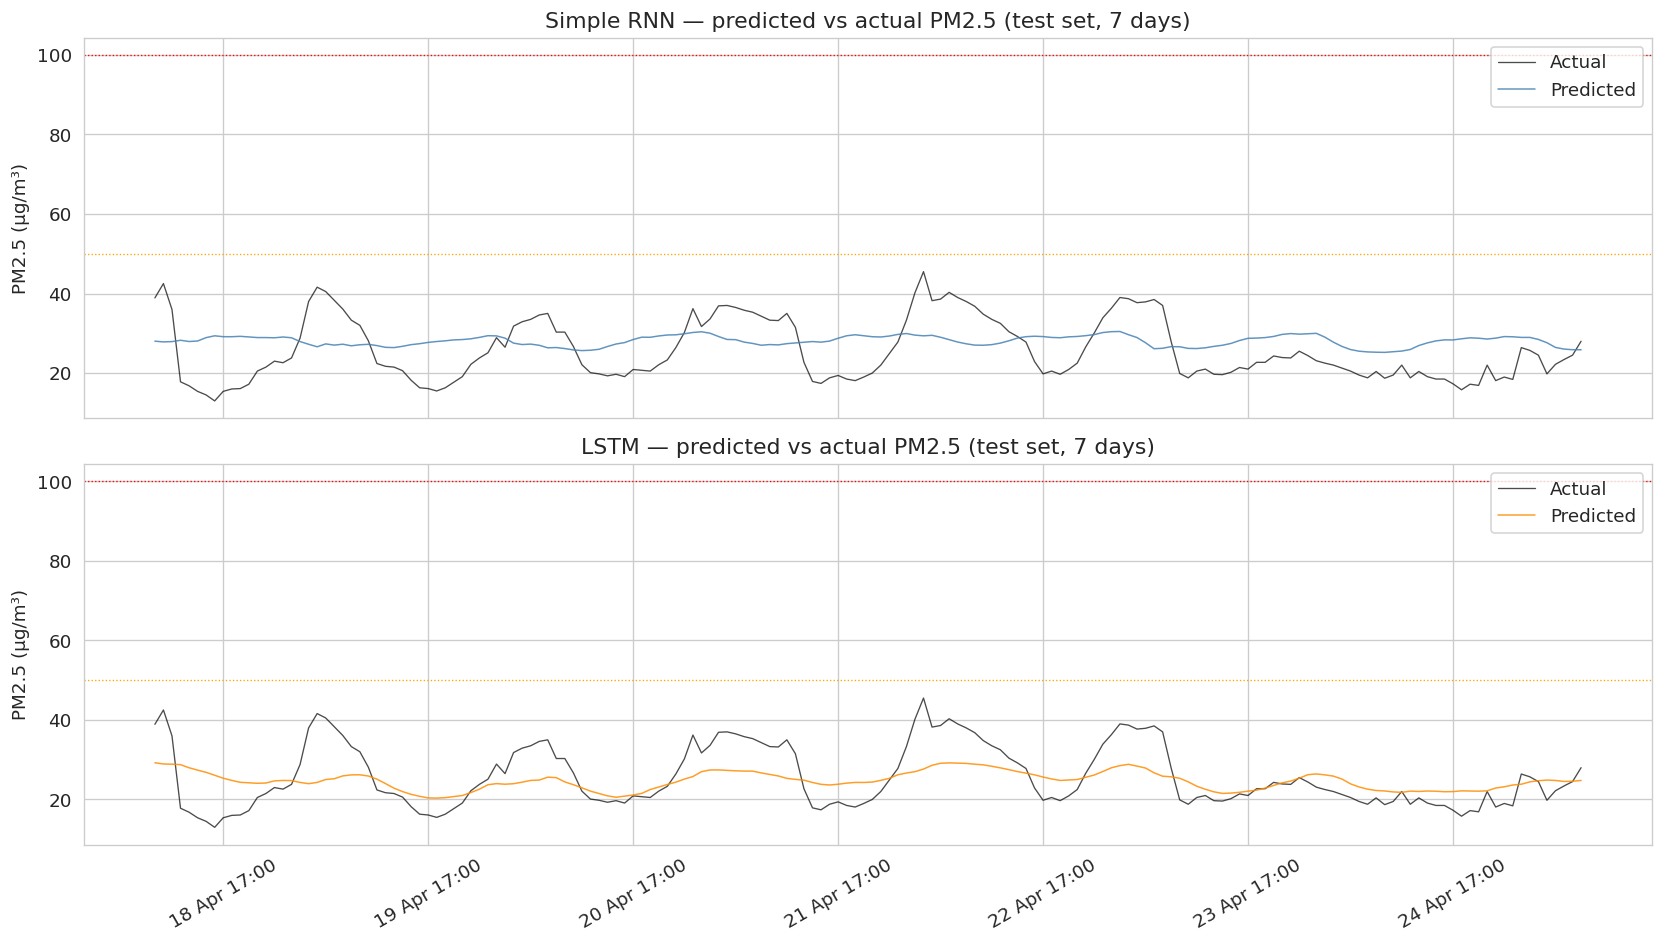

In [54]:
# ── Plot 3: Predicted vs actual PM2.5 on the test set (first 7 days) ──────────
# We show the first 7 * 24 = 168 hours of the test set for readability.

# Reconstruct the full time index for test predictions
# Each sample predicts 24 hours; we use the first prediction step only
# to produce a continuous 1-step-ahead comparison curve.

def get_onestep_preds(preds_all, truth_all, scaler, target_idx, n_features):
    """Extract 1-step-ahead predictions (hour +1) from the multi-step output."""
    def inv(arr):
        d = np.zeros((len(arr), n_features))
        d[:, target_idx] = arr
        return scaler.inverse_transform(d)[:, target_idx]
    return inv(preds_all[:, 0]), inv(truth_all[:, 0])


rnn_onestep,  rnn_truth_1s  = get_onestep_preds(
    rnn_preds_all,  rnn_truth_all,  scaler, TARGET_IDX, N_FEATURES)
lstm_onestep, lstm_truth_1s = get_onestep_preds(
    lstm_preds_all, lstm_truth_all, scaler, TARGET_IDX, N_FEATURES)

# Test set datetime index (aligned to samples)
test_dates = df_feat.index[val_end + SEQ_LEN : val_end + SEQ_LEN + len(rnn_onestep)]

SHOW = min(168, len(test_dates))  # show up to 7 days

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, preds, title, color in zip(
    axes,
    [rnn_onestep, lstm_onestep],
    ['Simple RNN — predicted vs actual PM2.5 (test set, 7 days)',
     'LSTM — predicted vs actual PM2.5 (test set, 7 days)'],
    ['steelblue', 'darkorange']
):
    ax.plot(test_dates[:SHOW], rnn_truth_1s[:SHOW],
            color='black', linewidth=0.8, label='Actual', alpha=0.7)
    ax.plot(test_dates[:SHOW], preds[:SHOW],
            color=color, linewidth=0.9, label='Predicted', alpha=0.85)
    ax.axhline(50,  color='orange', linestyle=':', linewidth=0.8)
    ax.axhline(100, color='red',    linestyle=':', linewidth=0.8)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(title)
    ax.legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', bbox_inches='tight')
plt.show()

In [55]:
# ── Final summary table ───────────────────────────────────────────────────────

print('=' * 55)
print('          FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'{"Metric":<28} {"Simple RNN":>12} {"LSTM":>12}')
print('-' * 55)
print(f'{"RMSE (µg/m³)":<28} {rnn_rmse:>12.3f} {lstm_rmse:>12.3f}')
print(f'{"MAE  (µg/m³)":<28} {rnn_mae:>12.3f} {lstm_mae:>12.3f}')

for name, t, p in [('RNN', rnn_truth_cls, rnn_preds_cls),
                    ('LSTM', lstm_truth_cls, lstm_preds_cls)]:
    prec = precision_score(t, p, average='macro', zero_division=0)
    rec  = recall_score(   t, p, average='macro', zero_division=0)
    f1   = f1_score(       t, p, average='macro', zero_division=0)
    col  = name
    print(f'{"Precision (AQI macro)":<28} {prec:>12.3f}' if name == 'RNN' else
          f'{"":28} {prec:>12.3f}')

# Cleaner approach for the last 3 rows
rnn_prec  = precision_score(rnn_truth_cls,  rnn_preds_cls,  average='macro', zero_division=0)
lstm_prec = precision_score(lstm_truth_cls, lstm_preds_cls, average='macro', zero_division=0)
rnn_rec   = recall_score(   rnn_truth_cls,  rnn_preds_cls,  average='macro', zero_division=0)
lstm_rec  = recall_score(   lstm_truth_cls, lstm_preds_cls, average='macro', zero_division=0)
rnn_f1    = f1_score(       rnn_truth_cls,  rnn_preds_cls,  average='macro', zero_division=0)
lstm_f1   = f1_score(       lstm_truth_cls, lstm_preds_cls, average='macro', zero_division=0)

print(f'{"Precision (AQI macro)":<28} {rnn_prec:>12.3f} {lstm_prec:>12.3f}')
print(f'{"Recall    (AQI macro)":<28} {rnn_rec:>12.3f}  {lstm_rec:>12.3f}')
print(f'{"F1        (AQI macro)":<28} {rnn_f1:>12.3f}  {lstm_f1:>12.3f}')
print('=' * 55)

          FINAL MODEL COMPARISON SUMMARY
Metric                         Simple RNN         LSTM
-------------------------------------------------------
RMSE (µg/m³)                       11.073       10.668
MAE  (µg/m³)                        8.424        7.859
Precision (AQI macro)               0.341
                                    0.385
Precision (AQI macro)               0.341        0.385
Recall    (AQI macro)               0.339         0.390
F1        (AQI macro)               0.268         0.374
